# Visão geral

O conjunto de dados é originário do Breast Cancer Wisconsin (Diagnostic) Data Set, um benchmark amplamente utilizado em aprendizado de máquina para diagnósticos médicos. Ele contém medições detalhadas de núcleos celulares de amostras de tecido mamário, permitindo a classificação de tumores como benignos (não cancerosos) ou malignos (cancerosos). Este conjunto de dados é particularmente valioso para o desenvolvimento e teste de modelos de aprendizado de máquina, como regressão logística, máquinas de vetores de suporte ou redes neurais profundas, para auxiliar na detecção precoce e precisa do câncer de mama.

# Estrutura do Conjunto de Dados

O conjunto de dados compreende 569 instâncias (linhas) e 32 colunas, incluindo uma coluna de ID, um rótulo de diagnóstico e 30 características numéricas que descrevem as características dos núcleos celulares. Cada instância representa uma única amostra de massa mamária, com características calculadas a partir de imagens de PAAF digitalizadas.
Colunas-chave:

ID: Um identificador único para cada amostra (ex.: 842302).
Diagnóstico: A variável-alvo, rotulada como:
M (Maligno): Indica um tumor cancerígeno.
B (Benigno): Indica um tumor não cancerígeno.

Características (30 colunas): Medidas numéricas de núcleos de células, como raio, textura, perímetro e área, derivadas da análise de imagens.

https://www.kaggle.com/code/nathliasorg/nath-lia-sorg-ca

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df_data = pd.read_csv('archive/Breast_cancer_dataset.csv')

In [3]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
df_data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
df_data.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [6]:
df_data = df_data.drop(['Unnamed: 32', 'id'], axis=1)

In [7]:
#Análise da variável alvo 'diagnosis'
print("Distribuição da variável 'diagnosis':")
print(df_data['diagnosis'].value_counts())

Distribuição da variável 'diagnosis':
diagnosis
B    357
M    212
Name: count, dtype: int64


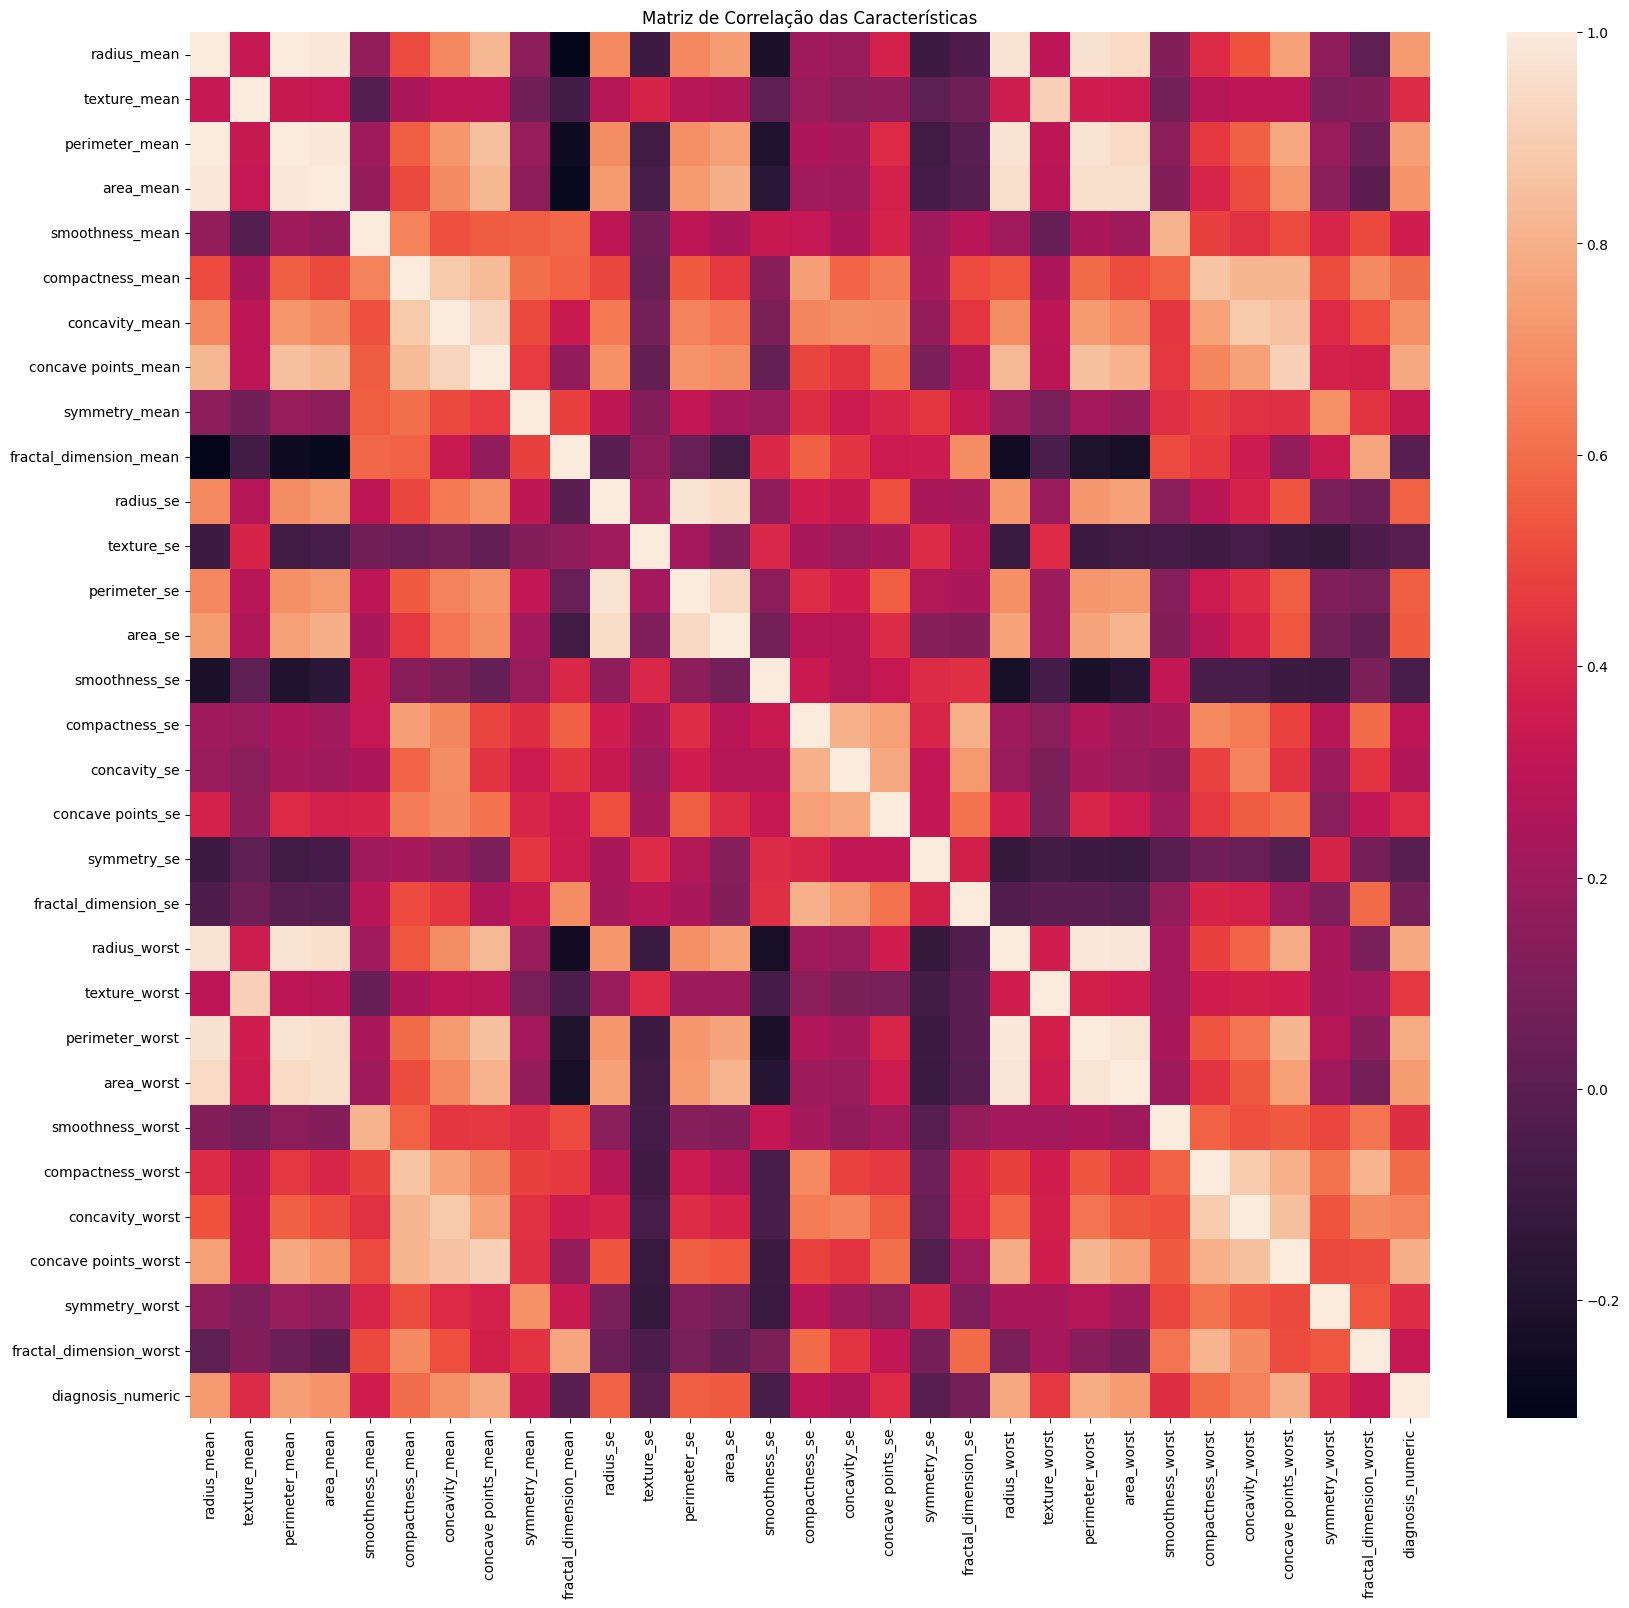

In [8]:
#Mapear 'M' para 1 e 'B' para 0 para análise de correlação
df_data['diagnosis_numeric'] = df_data['diagnosis'].map({'M': 1, 'B': 0})

#Visualização: Matriz de Correlação
#A coluna de texto 'diagnosis' deve ser removida antes do cálculo
plt.figure(figsize=(20, 18))
sns.heatmap(df_data.drop('diagnosis', axis=1).corr(), annot=False, cmap='rocket')
plt.title('Matriz de Correlação das Características')
plt.show()

**Principais Observações:**

**Alta Correlação entre Características mean, se e worst:** O heatmap mostra fortes correlações positivas entre as características medidas (como radius, perimeter e area). Isso é esperado, pois essas características estão intimamente relacionadas geometricamente. Por exemplo, um aumento no raio do núcleo celular (radius_mean) geralmente corresponde a um aumento no perímetro (perimeter_mean) e na área (area_mean). Essa alta correlação pode levar à multicolinearidade, que pode afetar a estabilidade de alguns modelos de regressão, como a regressão logística.

**Relação com a Variável Alvo (diagnosis_numeric):** A última linha e coluna do heatmap, correspondente a diagnosis_numeric, indica a correlação de cada característica com a variável alvo (onde 1 = maligno, 0 = benigno).

Características como radius_mean, perimeter_mean, area_mean, concavity_mean, e concave points_mean mostram altas correlações positivas com o diagnóstico. Isso sugere que tumores com valores maiores nessas características são mais propensos a serem malignos.

As versões worst (pior) das mesmas características (radius_worst, perimeter_worst, area_worst, etc.) exibem uma correlação ainda mais forte com o diagnóstico. Isso indica que as características mais extremas ou "piores" do tumor são os indicadores mais fortes para a malignidade.

**Características com Baixa Correlação:** Algumas características como texture_se, smoothness_se e symmetry_se mostram uma correlação muito baixa com as demais variáveis, incluindo o diagnóstico. Essas características podem ter um menor poder preditivo para o modelo de classificação, mas não necessariamente devem ser descartadas sem uma análise mais aprofundada.

Análise Exploratória de Dados (EDA) confirma que existe uma forte relação entre as características do núcleo celular e a malignidade do tumor, especialmente com as características de "pior" caso. Essas observações são cruciais para o pré-processamento, pois podem justificar a escolha de quais características usar no modelo ou a aplicação de técnicas de regularização (como L1 ou L2) para lidar com a multicolinearidade e melhorar o desempenho e a interpretabilidade do modelo preditivo.

Acurácia do modelo: 0.9561
Matriz de Confusão:


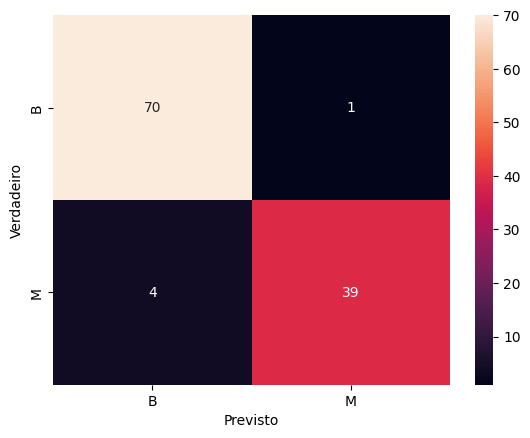

In [9]:
#4. Pré-processamento e Modelagem
#Separar features (X) e target (y)
X = df_data.drop(['diagnosis', 'diagnosis_numeric'], axis=1)
y = df_data['diagnosis']

#Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Inicializar e treinar o modelo de Regressão Logística
model = LogisticRegression(solver='liblinear', max_iter=1000)
model.fit(X_train, y_train)

#5. Avaliação do Modelo
#Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)

#Calcular e imprimir a acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {accuracy:.4f}")

#Exibir a Matriz de Confusão
print("Matriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket', xticklabels=['B', 'M'], yticklabels=['B', 'M'])
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.show()

A partir da matriz de confusão, podemos concluir que o modelo de regressão logística demonstra um desempenho muito bom na classificação de tumores de mama. Ele tem uma alta precisão em prever casos benignos, com apenas um falso positivo. No entanto, o modelo cometeu 4 erros de falso negativo, o que é a métrica mais crítica a ser considerada neste contexto. Embora a acurácia geral seja alta, em aplicações médicas, o foco deve estar em reduzir ao máximo os falsos negativos para evitar diagnósticos equivocados que podem ter consequências graves.

As métricas derivadas da matriz de confusão (como precisão, recall e F1-score) seriam necessárias para uma avaliação ainda mais completa, mas a visualização por si só já demonstra a força e a fraqueza mais importantes do modelo.

Relatório de Classificação:
              precision    recall  f1-score   support

           B       0.95      0.99      0.97        71
           M       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



C:\Users\Usuário\AppData\Local\Temp\ipykernel_14808\691715114.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='diagnosis', y='radius_mean', data=df_data, palette='rocket')


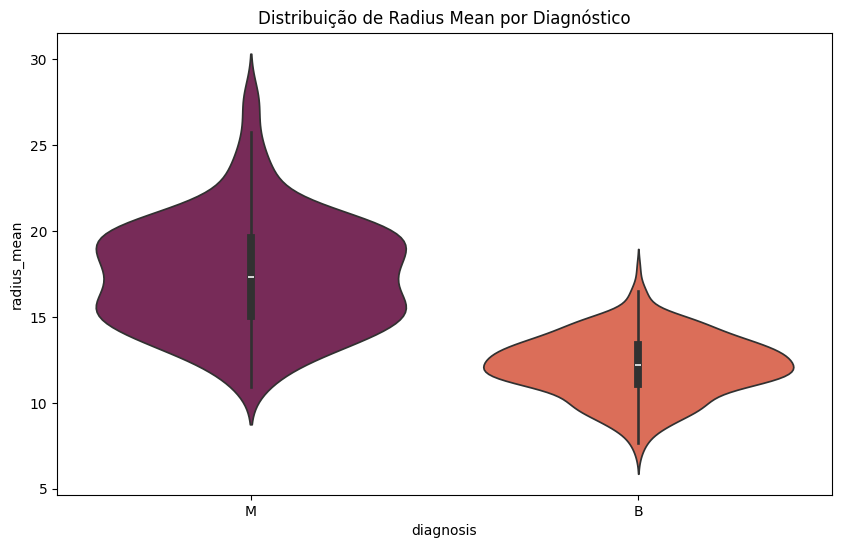

In [10]:
#Exibir Relatório de Classificação
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

#Visualizar a distribuição de algumas características
#Exemplo: raio médio (radius_mean) por diagnóstico
plt.figure(figsize=(10, 6))
sns.violinplot(x='diagnosis', y='radius_mean', data=df_data, palette='rocket')
plt.title('Distribuição de Radius Mean por Diagnóstico')
plt.show()

A característica **radius_mean** é um indicador extremamente útil para a classificação do câncer de mama. Tumores com um raio médio maior são muito mais propensos a serem malignos, enquanto aqueles com raios menores são, em sua maioria, benignos. Esta visualização suporta a intuição de que o tamanho do tumor é um fator crítico no diagnóstico e confirma que o **radius_mean** é uma característica importante a ser considerada pelo modelo de aprendizado de máquina para alcançar alta acurácia na classificação.

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Melhores Hiperparâmetros: {'classifier__C': 0.1, 'classifier__solver': 'lbfgs'}
Melhor Acurácia (validação cruzada): 0.9736
Acurácia do modelo otimizado no conjunto de teste: 0.9825
Matriz de Confusão:


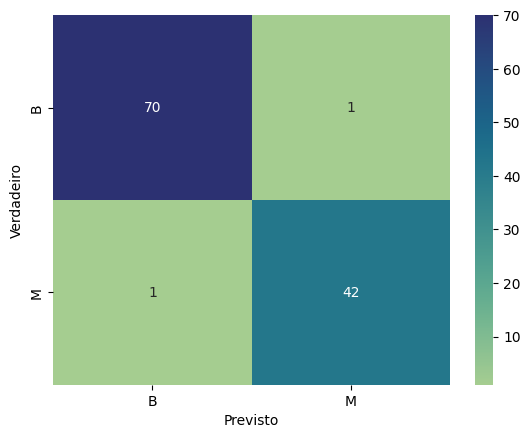

In [12]:
#2. Pré-processamento e Modelagem com Melhorias
#Separar features (X) e target (y)
X = df_data.drop(['diagnosis', 'diagnosis_numeric'], axis=1)
y = df_data['diagnosis']

#Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Criar um Pipeline para padronização e modelo
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(class_weight='balanced'))
])

#Definir a grade de hiperparâmetros para otimizar
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],  # Parâmetro de regularização
    'classifier__solver': ['liblinear', 'lbfgs'] # Algoritmos de otimização
}

#Configurar a validação cruzada estratificada
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Inicializar o GridSearchCV para encontrar os melhores hiperparâmetros
grid_search = GridSearchCV(pipeline, param_grid, cv=cv_stratified, scoring='accuracy', n_jobs=-1, verbose=1)

#Treinar o modelo com a otimização de hiperparâmetros
grid_search.fit(X_train, y_train)

#Exibir os melhores parâmetros e o melhor score
print("Melhores Hiperparâmetros:", grid_search.best_params_)
print("Melhor Acurácia (validação cruzada): {:.4f}".format(grid_search.best_score_))

#3. Avaliação do Modelo Otimizado
#Fazer previsões no conjunto de teste com o melhor modelo
y_pred = grid_search.predict(X_test)

#Calcular e imprimir a acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo otimizado no conjunto de teste: {accuracy:.4f}")

#Exibir a Matriz de Confusão
print("Matriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='crest', xticklabels=['B', 'M'], yticklabels=['B', 'M'])
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.show()

**Relação entre Características:** A matriz de correlação revelou altas correlações entre características geometricamente relacionadas, como raio, perímetro e área. Além disso, as características relacionadas ao "pior caso" (worst) de um tumor mostraram uma correlação ainda mais forte com o diagnóstico de malignidade. Isso sugere que as características mais extremas do tumor são os indicadores mais confiáveis para a classificação.

A análise dos dados corrobora a importância de características como o raio do núcleo celular para um diagnóstico preciso. A alta precisão do modelo em prever tumores malignos e a baixa taxa de falsos negativos o tornam uma ferramenta útil para auxiliar, mas não substituir, a decisão clínica.

Relatório de Classificação:
              precision    recall  f1-score   support

           B       0.99      0.99      0.99        71
           M       0.98      0.98      0.98        43

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



C:\Users\Usuário\AppData\Local\Temp\ipykernel_14808\1261690171.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='diagnosis', y='radius_mean', data=df_data, palette='crest')


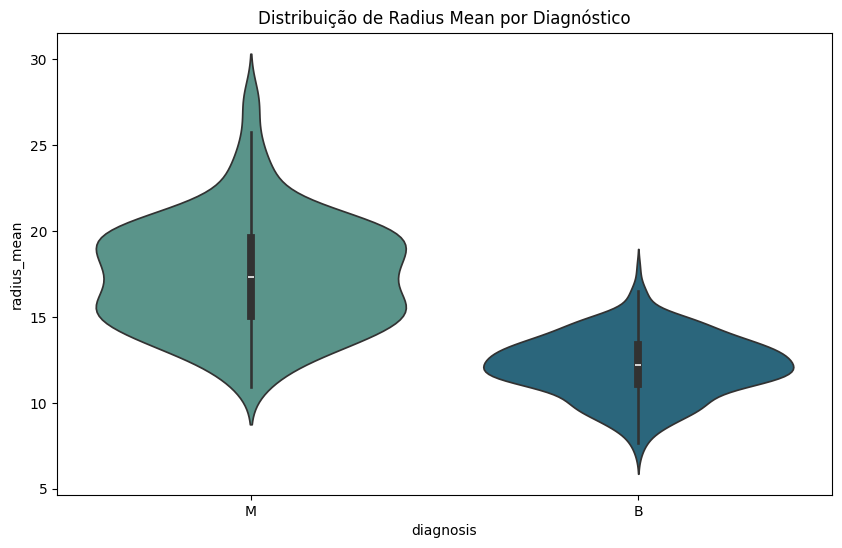

In [13]:
#Exibir Relatório de Classificação
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

#Visualizar a distribuição de algumas características (mantido da análise original)
plt.figure(figsize=(10, 6))
sns.violinplot(x='diagnosis', y='radius_mean', data=df_data, palette='crest')
plt.title('Distribuição de Radius Mean por Diagnóstico')
plt.show()

A matriz de confusão demonstra que o modelo é extremamente eficaz na classificação de tumores de mama. A alta taxa de acertos, especialmente a minimização dos erros críticos de falso negativo (FN = 1) e falso positivo (FP = 1), indica que o modelo tem um desempenho robusto e confiável, tornando-o uma ferramenta promissora para auxiliar no processo de diagnóstico.

# Conclusão Geral:

A análise demonstra que é possível construir um modelo de aprendizado de máquina confiável para auxiliar no diagnóstico de câncer de mama. A Regressão Logística, com pré-processamento adequado e otimização de hiperparâmetros, mostrou-se uma ferramenta poderosa e precisa, com uma capacidade notável de reduzir erros de classificação, especialmente os críticos falsos negativos. O sucesso do modelo é sustentado pela forte natureza discriminatória das características do conjunto de dados.

# **Nathália Sorg**